In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../data/cleaned/ipo_cleaned.csv')
print("Shape:", df.shape)
print("\nNull check:")
print(df.isnull().sum())

Shape: (549, 19)

Null check:
Date                   0
IPO_Name               0
Issue_Size(crores)     0
QIB                    0
HNI                    0
RII                    0
Total                  0
Offer Price            0
List Price             0
Listing Gain           0
CMP(BSE)               0
CMP(NSE)               0
Current Gains          0
Year                   0
Month                  0
Issue_Size_Category    0
Subscription_Tier      0
QIB_vs_RII             0
Listing_Category       0
dtype: int64


In [2]:
print("Listing Gain Statistics")
print(df['Listing Gain'].describe().round(2))

# Count profitable vs loss IPOs
profitable = (df['Listing Gain'] > 0).sum()
loss = (df['Listing Gain'] < 0).sum()
flat = (df['Listing Gain'] == 0).sum()
total = len(df)

print(f"\nProfitable on listing day: {profitable} ({profitable/total*100:.1f}%)")
print(f"Loss on listing day        : {loss} ({loss/total*100:.1f}%)")
print(f"Flat on listing day        : {flat} ({flat/total*100:.1f}%)")

Listing Gain Statistics
count    549.00
mean      18.26
std       32.20
min      -31.73
25%        0.00
50%        7.15
75%       26.86
max      252.76
Name: Listing Gain, dtype: float64

Profitable on listing day: 381 (69.4%)
Loss on listing day        : 137 (25.0%)
Flat on listing day        : 31 (5.6%)


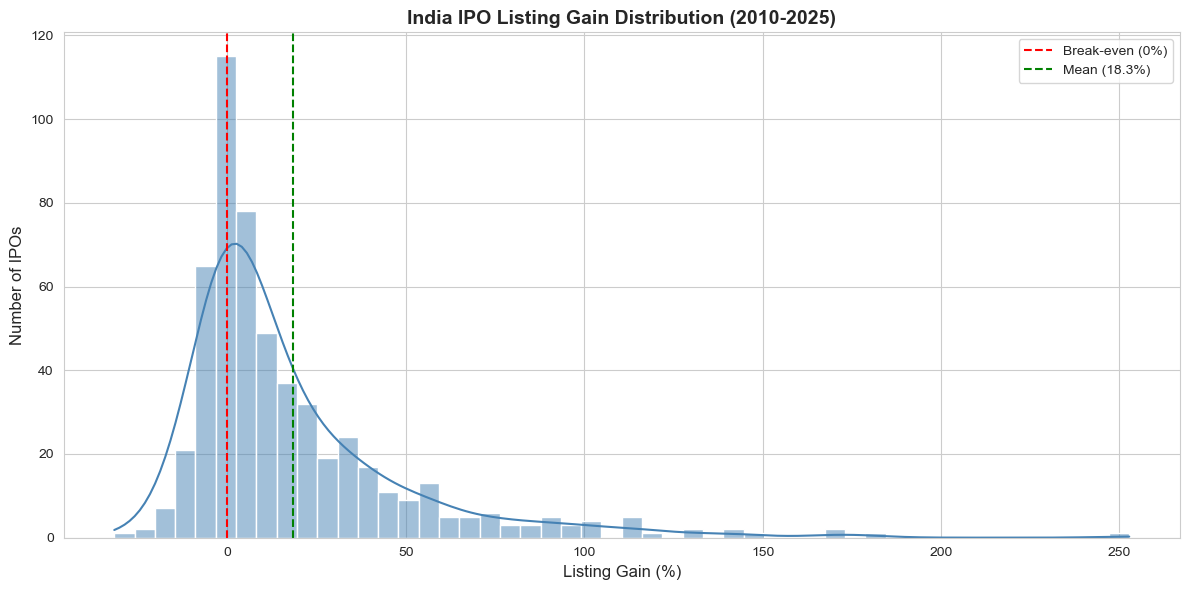

Chart saved to charts/


In [3]:
# Set consistent style for all EDA charts
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

fig, ax = plt.subplots()

# Plot histogram with KDE curve overlay
sns.histplot(
    data=df,
    x='Listing Gain',
    bins=50,
    kde=True,
    color='steelblue',
    edgecolor='white',
    ax=ax
)

# Add vertical line at 0 — separates profit from loss
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Break-even (0%)')

# Add vertical line at mean
mean_gain = df['Listing Gain'].mean()
ax.axvline(x=mean_gain, color='green', linestyle='--',
           linewidth=1.5, label=f'Mean ({mean_gain:.1f}%)')

# Labels and title
ax.set_title('India IPO Listing Gain Distribution (2010-2025)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Listing Gain (%)', fontsize=12)
ax.set_ylabel('Number of IPOs', fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig('../charts/01_listing_gain_distribution.png', dpi=150)
plt.show()
print("Chart saved to charts/")

## EDA Q1 — Listing Gain Distribution: Key Findings

Most IPOs are clustered between 0% and 30%.
Mean is 18.3% but median is only 7.15% — a few big 
winners like 200%+ are pulling the average up.
So typical IPO gives around 7%, not 18%.l (big gains)?
Or were they spread evenly? That is Day 8's answer.